# Intelligent News Article Classification and Fake News Detection using NLP

**Assignment PS-5 | NLP Pipeline**

This notebook implements a complete NLP pipeline covering:
1. Data Preprocessing
2. Exploratory Data Analysis
3. Vector Embeddings (Word2Vec, TF-IDF)
4. Neural Language Model (LSTM)
5. POS Tagging (NLTK + SpaCy)
6. Hidden Markov Model (HMM)
7. Syntactic Parsing
8. News Classification (LR, NB, RF)
9. Fake News Detection
10. Integrated Analysis Pipeline

---

## 0. Setup & Installation

**Dataset Setup:**
1. Download the **Fake and Real News Dataset** from Kaggle:
   - URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
2. Place `True.csv` and `Fake.csv` in a `data/` folder in the project root.

**Folder Structure:**
```
project/
├── data/
│   ├── True.csv
│   └── Fake.csv
├── src/
│   ├── preprocessing.py
│   ├── eda.py
│   ├── embeddings.py
│   ├── neural_lm.py
│   ├── pos_tagging.py
│   ├── hmm_model.py
│   ├── parsing.py
│   └── classifiers.py
├── models/          (auto-created for saved models)
├── NLP_Assignment.ipynb
├── requirements.txt
└── README.md
```

In [1]:
# Install dependencies (uncomment for Colab)
# !pip install pandas numpy scikit-learn nltk spacy gensim torch matplotlib seaborn hmmlearn wordcloud tqdm
# !python -m spacy download en_core_web_sm

In [ ]:
import sys, os, platform
import warnings
warnings.filterwarnings('ignore')

# Add src to path for imports
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import sklearn, nltk, spacy, gensim

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# ── Environment Information ──────────────────────────────────────────────────
print("=" * 65)
print("ENVIRONMENT INFORMATION")
print("=" * 65)
print(f"  OS           : {platform.system()} {platform.release()} ({platform.machine()})")
print(f"  Platform     : {platform.platform()}")
print(f"  CPU          : {platform.processor() or 'N/A'}")
print(f"  CPU Cores    : {os.cpu_count()}")
print(f"  Python       : {sys.version.split()[0]}")
print(f"  PyTorch      : {torch.__version__}")
print(f"  Scikit-learn : {sklearn.__version__}")
print(f"  NLTK         : {nltk.__version__}")
print(f"  SpaCy        : {spacy.__version__}")
print(f"  Gensim       : {gensim.__version__}")
print(f"  Pandas       : {pd.__version__}")
print(f"  NumPy        : {np.__version__}")
print(f"  Matplotlib   : {matplotlib.__version__}")
print(f"  Seaborn      : {sns.__version__}")
print("-" * 65)

# Device detection: Intel XPU (Arc GPU) > CUDA > CPU
if hasattr(torch, 'xpu') and torch.xpu.is_available():
    DEVICE = 'xpu'
    print(f"  Compute      : Intel XPU — {torch.xpu.get_device_name(0)}")
elif torch.cuda.is_available():
    DEVICE = 'cuda'
    print(f"  Compute      : CUDA — {torch.cuda.get_device_name(0)}")
else:
    DEVICE = 'cpu'
    n_cores = os.cpu_count() or 4
    torch.set_num_threads(n_cores)
    torch.set_num_interop_threads(min(n_cores, 4))
    print(f"  Compute      : CPU ({n_cores} threads)")
print("=" * 65)

Using device: Intel XPU — Intel(R) Arc(TM) Pro 140T GPU (16GB)
PyTorch version: 2.9.1+xpu


---
## 1. Data Loading & Preprocessing

We perform:
- **Lowercasing**: Normalize text case
- **Punctuation removal**: Remove non-alphanumeric characters
- **Stopword removal**: Remove common English stopwords
- **Tokenization**: Split text into individual words
- **Lemmatization**: Reduce words to base form (e.g., 'running' → 'run')
- **Missing value handling**: Fill NaN text with empty strings

In [3]:
from src.preprocessing import load_fake_real_dataset, preprocess_dataframe

# Load dataset
df = load_fake_real_dataset('data/True.csv', 'data/Fake.csv')
print(f"Dataset loaded: {df.shape[0]} articles")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset loaded: 44898 articles
Columns: ['index', 'title', 'text', 'subject', 'date', 'label']


,index,title,text,subject,date,label
0,22216,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,27917,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,25007,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,1377,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,32476,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
if 'subject' in df.columns:
    print(f"\nSubjects:\n{df['subject'].value_counts()}")

Missing values:
index      0
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Subjects:
subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


In [5]:
# Preprocess text
print("Preprocessing text... (this may take a few minutes)")
df = preprocess_dataframe(df, text_col='text')
print("Preprocessing complete!")

# Show example
print(f"\nOriginal: {df['text'].iloc[0][:200]}...")
print(f"\nCleaned: {df['cleaned'].iloc[0][:200]}...")
print(f"\nTokens: {df['tokens'].iloc[0][:20]}")

Preprocessing text... (this may take a few minutes)
Preprocessing complete!

Original: Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour, and they refuse to acknowledge that there are problems surrounding all of th...

Cleaned: donald trump s white house is in chaos and they are trying to cover it up their russia problems are mounting by the hour and they refuse to acknowledge that there are problems surrounding all of this ...

Tokens: ['donald', 'trump', 'white', 'house', 'chaos', 'trying', 'cover', 'russia', 'problem', 'mounting', 'hour', 'refuse', 'acknowledge', 'problem', 'surrounding', 'fake', 'news', 'hoax', 'however', 'fact']


---
## 2. Exploratory Data Analysis

We analyze:
- Class distribution (Fake vs Real)
- Category/subject distribution
- Word clouds for each class
- Most frequent words
- Article length distribution

EXPLORATORY DATA ANALYSIS

Dataset shape: (44898, 9)

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Category distribution:
subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


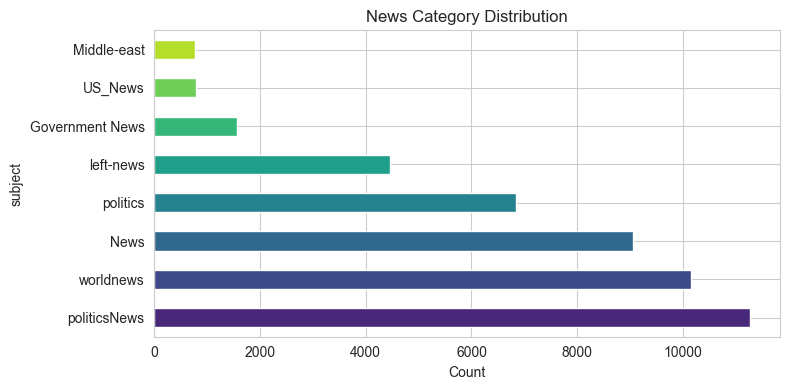

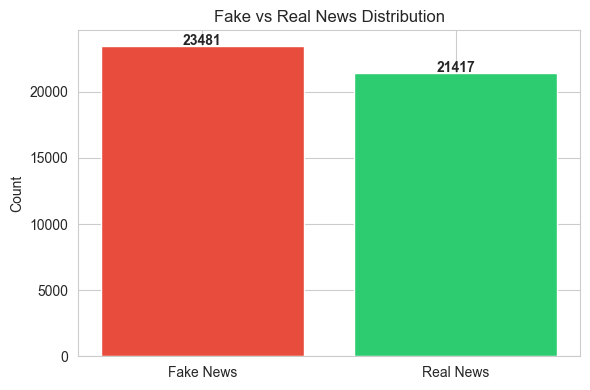

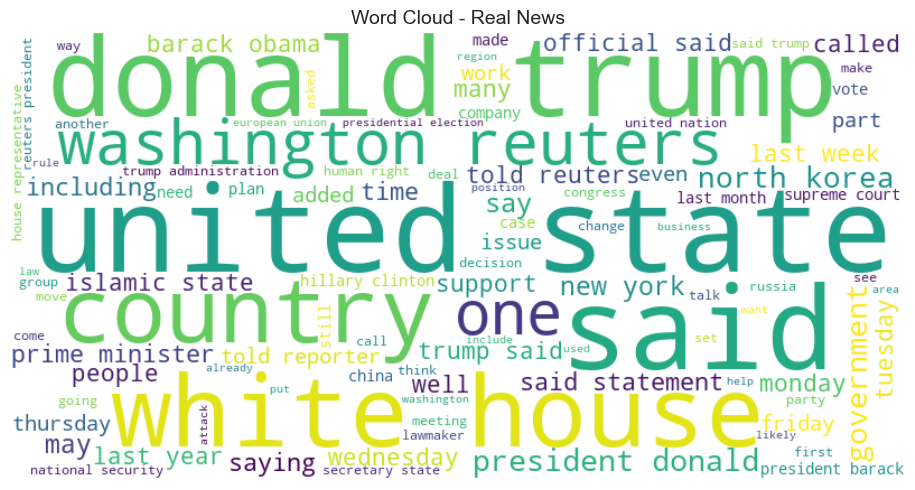

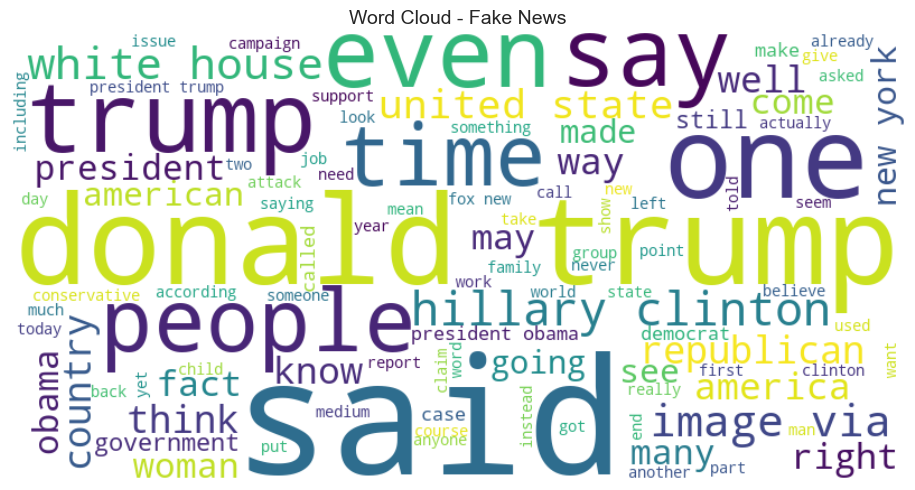

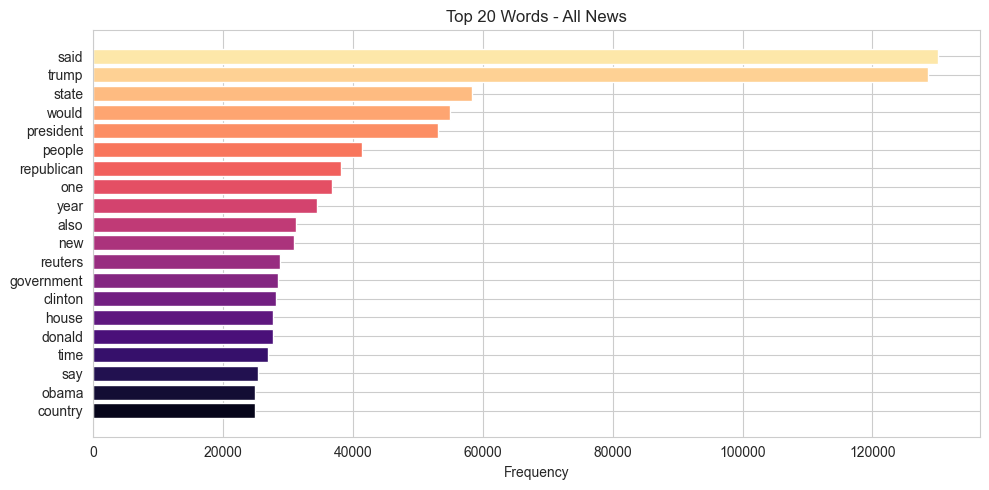

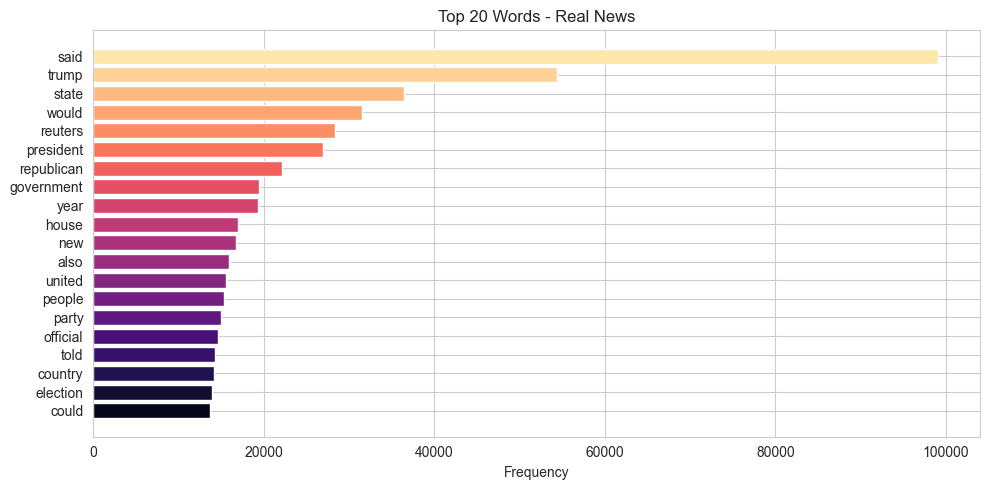

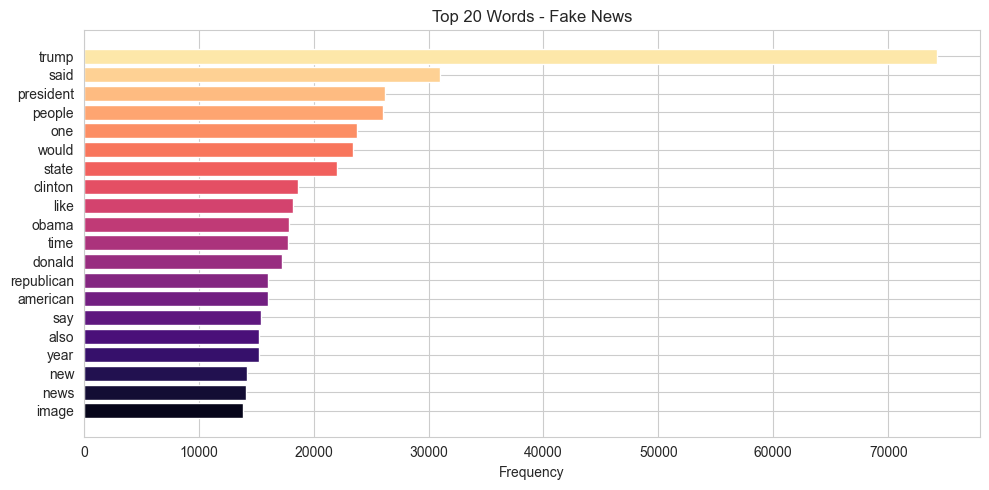

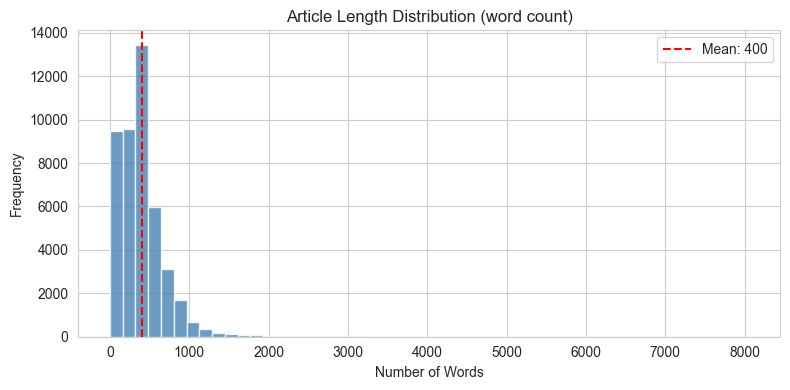

In [6]:
from src.eda import run_full_eda
run_full_eda(df)

---
## 3. Vector Embeddings

We implement:
- **Word2Vec**: Neural embedding model trained on our corpus
- **TF-IDF**: Term frequency-inverse document frequency vectors

Word2Vec captures semantic relationships between words, while TF-IDF captures term importance.

In [7]:
from src.embeddings import train_word2vec, build_tfidf, show_similar_words, show_semantic_similarity, get_document_vector_w2v

# Train Word2Vec
w2v_model = train_word2vec(df['tokens'].tolist(), vector_size=100, window=5, min_count=3, epochs=15)

# Build TF-IDF
tfidf_vectorizer, tfidf_matrix = build_tfidf(df['processed_text'].tolist(), max_features=10000)

Building co-occurrence matrix (PPMI + SVD Word2Vec)...
Word2Vec (PPMI+SVD) trained: vocab=20000, dim=100, explained_var=0.256
TF-IDF matrix shape: (44898, 10000)


In [8]:
# Semantic similarity examples
for word in ['trump', 'election', 'health', 'technology', 'sports', 'economy']:
    show_similar_words(w2v_model, word, topn=5)

# Word pair similarities
pairs = [
    ('president', 'government'), ('fake', 'real'),
    ('democrat', 'republican'), ('health', 'medical'),
    ('economy', 'market'), ('war', 'peace')
]
show_semantic_similarity(w2v_model, pairs)


Words most similar to 'trump':
  donald               0.9397
  kellyanne            0.9169
  spicer               0.8819
  conway               0.8796
  unfit                0.8703

Words most similar to 'election':
  electoral            0.8689
  poll                 0.8476
  polling              0.8175
  turnout              0.8109
  party                0.8107

Words most similar to 'health':
  newborn              0.8320
  medicaid             0.8263
  patient              0.8243
  care                 0.8080
  doctor               0.8063

Words most similar to 'technology':
  startup              0.8678
  electric             0.8571
  motor                0.8369
  automobile           0.8358
  facebooks            0.8204
'sports' not in vocabulary.

Words most similar to 'economy':
  economist            0.8600
  sector               0.8563
  market               0.8553
  boosting             0.8527
  currency             0.8510

Semantic Similarity (Word2Vec):
------------------

---
## 4. Neural Language Model (LSTM)

We build an **LSTM-based Neural Language Model** that:
- Learns language patterns from news articles
- Predicts the next word given a sequence of words
- Demonstrates contextual understanding of news language

**Architecture:** Embedding → 2-layer LSTM → Fully Connected → Softmax

In [ ]:
from src.neural_lm import (TextDataset, LSTMLanguageModel, build_vocab,
                            train_language_model, predict_next_words, plot_loss_curve)
from torch.utils.data import DataLoader

# Adaptive parameters based on device
if DEVICE == 'cpu':
    N_ARTICLES  = 2000      # fewer articles for CPU
    BATCH_SIZE  = 64
    LM_EPOCHS   = 10
else:
    N_ARTICLES  = 5000      # more data when GPU is available
    BATCH_SIZE  = 256
    LM_EPOCHS   = 15

sample_tokens = df['tokens'].tolist()[:N_ARTICLES]

# Build vocabulary
word2idx, idx2word = build_vocab(sample_tokens, min_freq=3)

# Create dataset
SEQ_LENGTH = 10
dataset = TextDataset(sample_tokens, word2idx, seq_length=SEQ_LENGTH)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Device: {DEVICE} | Articles: {N_ARTICLES} | Batch: {BATCH_SIZE} | Epochs: {LM_EPOCHS}")
print(f"Training sequences: {len(dataset)}")

Vocabulary size: 20497
Training sequences: 1074825


Model parameters: 4,187,345

Training Neural Language Model...
  Epoch 1/15, Loss: 8.0056
  Epoch 2/15, Loss: 7.6476
  Epoch 4/15, Loss: 7.3178
  Epoch 6/15, Loss: 7.1486
  Epoch 8/15, Loss: 7.0350
  Epoch 10/15, Loss: 6.9524
  Epoch 12/15, Loss: 6.8876
  Epoch 14/15, Loss: 6.8351


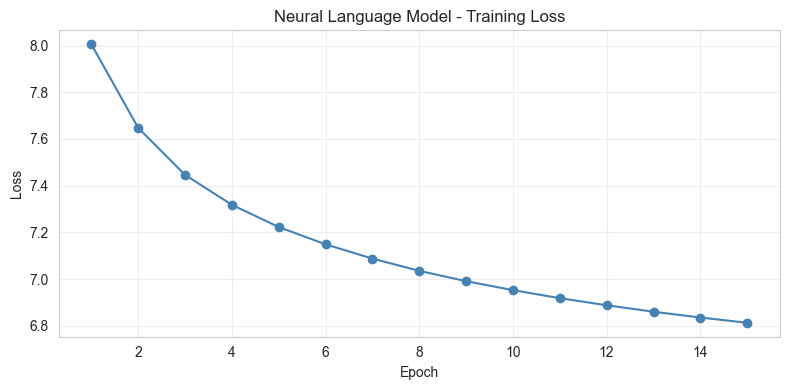

In [ ]:
# Build and train model
vocab_size = len(word2idx)
lm_model = LSTMLanguageModel(vocab_size, embed_dim=64, hidden_dim=128, num_layers=2)
print(f"Model parameters: {sum(p.numel() for p in lm_model.parameters()):,}")

print("\nTraining Neural Language Model...")
losses = train_language_model(lm_model, dataloader, epochs=LM_EPOCHS, lr=0.002, device=DEVICE)
plot_loss_curve(losses)

In [11]:
# Next word prediction examples
seed_texts = [
    "the president said that the",
    "breaking news from the white",
    "the government announced new policy",
    "according to official report the",
]

print("Next Word Predictions:")
print("=" * 60)
for seed in seed_texts:
    result = predict_next_words(lm_model, seed, word2idx, idx2word,
                                seq_length=SEQ_LENGTH, n_words=5, device=DEVICE)
    print(f"  Input: '{seed}'")
    print(f"  Output: '{result}'\n")

Next Word Predictions:
  Input: 'the president said that the'
  Output: 'the president said that the would college democratic process tom'

  Input: 'breaking news from the white'
  Output: 'breaking news from the white house press secretary perry reported'

  Input: 'the government announced new policy'
  Output: 'the government announced new policy remaining publicly currently trump move'

  Input: 'according to official report the'
  Output: 'according to official report the quote system moment new <UNK>'



---
## 5. POS Tagging

Part-of-Speech tagging identifies the grammatical role of each word:
- **Nouns (NN)**: People, places, things
- **Verbs (VB)**: Actions
- **Adjectives (JJ)**: Descriptors
- **Named Entities**: People, organizations, locations

We use both **NLTK** and **SpaCy** for comparison.

In [12]:
import spacy

try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Downloading SpaCy model...")
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

print("SpaCy model loaded.")

SpaCy model loaded.


In [13]:
from src.pos_tagging import display_pos_summary

# Analyze sample articles
for i, idx in enumerate([0, 1, 2]):
    label = 'REAL' if df['label'].iloc[idx] == 1 else 'FAKE'
    print(f"\n{'#' * 60}")
    print(f"Article {i+1} ({label})")
    print(f"{'#' * 60}")
    sample_text = df['text'].iloc[idx][:1000]
    display_pos_summary(sample_text, nlp=nlp)


############################################################
Article 1 (FAKE)
############################################################

POS TAGGING ANALYSIS

Sample POS Tags (first 20): [('Donald', 'NNP'), ('Trump', 'NNP'), ('s', 'VBD'), ('White', 'NNP'), ('House', 'NNP'), ('is', 'VBZ'), ('in', 'IN'), ('chaos', 'NN'), (',', ','), ('and', 'CC'), ('they', 'PRP'), ('are', 'VBP'), ('trying', 'VBG'), ('to', 'TO'), ('cover', 'VB'), ('it', 'PRP'), ('up', 'RP'), ('.', '.'), ('Their', 'PRP$'), ('Russia', 'NN')]

Top Nouns: [('Trump', 6), ('Donald', 3), ('White', 2), ('problems', 2), ('fact', 2), ('House', 1), ('chaos', 1), ('Russia', 1), ('hour', 1), ('news', 1)]
Top Verbs: [('is', 4), ('are', 4), ('s', 3), ('seems', 3), ('trying', 1), ('cover', 1), ('mounting', 1), ('refuse', 1), ('acknowledge', 1), ('surrounding', 1)]
Top Adjectives: [('shady', 2), ('fake', 1), ('public', 1), ('former', 1), ('infamous', 1), ('Democratic', 1), ('due', 1), ('few', 1), ('Special', 1)]

Named Entities (first

---
## 6. Hidden Markov Model (HMM)

We use HMM for:
1. **POS Sequence Modeling**: Learning transition probabilities between POS tags
2. **Fake News Feature Extraction**: Modeling sequence patterns that differ between fake and real news

HMM captures:
- **Transition probabilities**: P(tag_t | tag_{t-1})
- **Emission probabilities**: P(word | tag)
- **Starting probabilities**: P(first tag in sentence)

In [14]:
from src.hmm_model import build_hmm_pos_tagger, display_hmm_results, hmm_fake_news_features
from src.pos_tagging import pos_tag_text

# Build POS-tagged sentences for HMM
print("POS tagging sample sentences for HMM...")
sample_texts = df['text'].iloc[:500].tolist()
tagged_sentences = []
for text in sample_texts:
    # Take first 50 words per article for speed
    words = text.split()[:50]
    tagged = pos_tag_text(' '.join(words))
    if len(tagged) > 3:
        tagged_sentences.append(tagged)

print(f"Tagged {len(tagged_sentences)} sentences")

# Build HMM
transition, start_probs, tag_encoder = build_hmm_pos_tagger(tagged_sentences)
display_hmm_results(transition, start_probs, tag_encoder)

POS tagging sample sentences for HMM...
Tagged 490 sentences
HMM POS Tagger built: 42 states (POS tags)
Transition matrix shape: (42, 42)

HIDDEN MARKOV MODEL ANALYSIS

Number of hidden states (POS tags): 42
States: [np.str_('#'), np.str_('$'), np.str_('('), np.str_(')'), np.str_(','), np.str_('.'), np.str_(':'), np.str_('CC'), np.str_('CD'), np.str_('DT'), np.str_('EX'), np.str_('FW'), np.str_('IN'), np.str_('JJ'), np.str_('JJR')]...

Starting probabilities (top 5):
  NNP  : 0.5816
  DT   : 0.1000
  IN   : 0.0592
  NN   : 0.0449
  JJ   : 0.0449

Sample transition probabilities:
  #     -> NNP  : 0.8571
  #     -> NNS  : 0.0714
  #     -> CD   : 0.0714
  $     -> CD   : 0.9231
  $     -> MD   : 0.0385
  $     -> JJ   : 0.0385
  (     -> NNP  : 0.7741
  (     -> NNPS : 0.1444
  (     -> CD   : 0.0148
  )     -> :    : 0.7865
  )     -> NNP  : 0.0599
  )     -> IN   : 0.0487
  ,     -> NNP  : 0.1794
  ,     -> DT   : 0.1368
  ,     -> VBG  : 0.0818


In [15]:
# HMM for fake vs real news sequence analysis
print("\nHMM Fake vs Real News Analysis:")
print("-" * 40)
hmm_results = hmm_fake_news_features(df.iloc[:2000], text_col='cleaned')


HMM Fake vs Real News Analysis:
----------------------------------------
  HMM for Fake news: n_states=4, entropy=1.3203, mean_state=0.2656
  HMM for Real news: n_states=4, entropy=0.7938, mean_state=0.1976


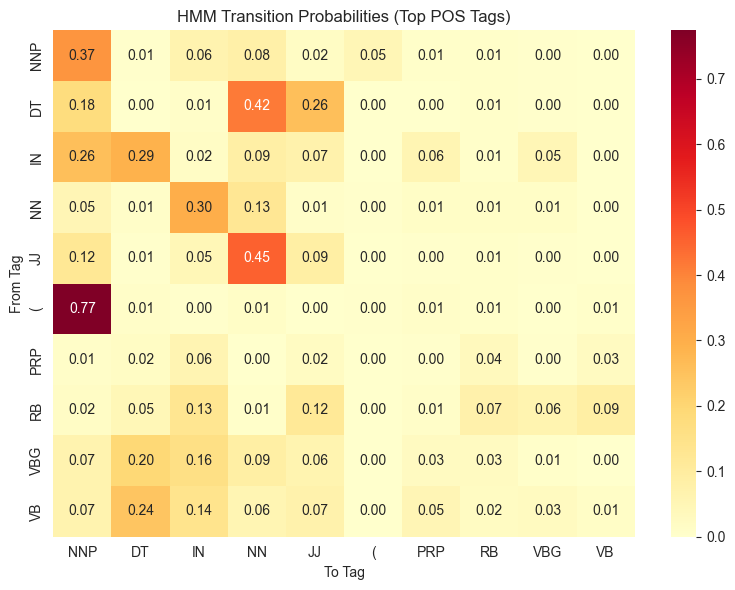

In [16]:
# Visualize transition matrix
top_n = 10
top_tags = np.argsort(start_probs)[::-1][:top_n]
tag_names = tag_encoder.classes_[top_tags]
sub_trans = transition[np.ix_(top_tags, top_tags)]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sub_trans, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=tag_names, yticklabels=tag_names, ax=ax)
ax.set_title('HMM Transition Probabilities (Top POS Tags)')
ax.set_xlabel('To Tag')
ax.set_ylabel('From Tag')
plt.tight_layout()
plt.show()

### 6b. HMM-Based Fake News Detection

Using per-document HMM sequence features (transition entropy + mean discrete state) as input to a classifier, we evaluate how well HMM probabilistic patterns alone can distinguish fake from real news.

Extracting per-document HMM sequence features...

HMM-BASED FAKE NEWS DETECTION RESULTS
Features used : transition entropy, mean discretised state
Classifier    : Logistic Regression on HMM features
Accuracy      : 0.7008
F1 (weighted) : 0.6843

Detailed Classification Report:
              precision    recall  f1-score   support

        Fake       0.65      0.91      0.76      4696
        Real       0.83      0.47      0.60      4284

    accuracy                           0.70      8980
   macro avg       0.74      0.69      0.68      8980
weighted avg       0.74      0.70      0.68      8980



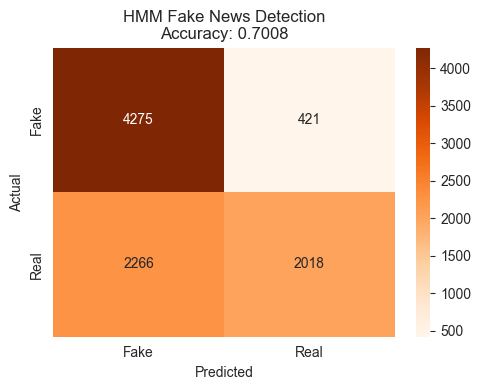

In [17]:
from src.hmm_model import hmm_classify_fake_news

# Run HMM-based fake news classification with evaluation metrics
hmm_acc, hmm_f1, hmm_y_test, hmm_y_pred, hmm_clf, hmm_features = hmm_classify_fake_news(
    df, text_col='cleaned', label_col='label'
)

---
## 7. Syntactic Parsing

We perform **dependency parsing** using SpaCy to:
- Analyze sentence structure
- Extract Subject-Verb-Object (SVO) triples
- Identify noun chunks
- Understand entity relationships

In [18]:
from src.parsing import display_parse_results

# Parse sample articles
for i in range(3):
    label = 'REAL' if df['label'].iloc[i] == 1 else 'FAKE'
    print(f"\n{'#' * 60}")
    print(f"Parsing Article {i+1} ({label})")
    print(f"{'#' * 60}")
    display_parse_results(df['text'].iloc[i], nlp)


############################################################
Parsing Article 1 (FAKE)
############################################################

SYNTACTIC PARSING ANALYSIS

Dependency Parse (first 15 tokens):
Token           POS      Dep          Head           
-------------------------------------------------------
Donald          PROPN    compound     Trump          
Trump           PROPN    poss         House          
s               PART     case         Trump          
White           PROPN    compound     House          
House           PROPN    nsubj        is             
is              AUX      ROOT         is             
in              ADP      prep         is             
chaos           NOUN     pobj         in             
,               PUNCT    punct        is             
and             CCONJ    cc           is             
they            PRON     nsubj        trying         
are             AUX      aux          trying         
trying          VERB     conj

---
## 8. News Classification

We train and compare three classifiers:
- **Logistic Regression**: Linear model, good baseline
- **Naive Bayes**: Probabilistic, fast, good for text
- **Random Forest**: Ensemble method, captures non-linear patterns

Features: TF-IDF vectors

In [19]:
from src.classifiers import (train_evaluate_classifiers, plot_confusion_matrices,
                              plot_comparison, print_classification_reports)

# Fake News Detection using TF-IDF features
print("=" * 60)
print("FAKE NEWS CLASSIFICATION")
print("=" * 60)

X = tfidf_matrix
y = df['label'].values

results, X_train, X_test, y_train, y_test = train_evaluate_classifiers(X, y)

FAKE NEWS CLASSIFICATION

Training Logistic Regression...
  Accuracy: 0.9885 | F1: 0.9885 | Precision: 0.9886 | Recall: 0.9885

Training Naive Bayes...
  Accuracy: 0.9492 | F1: 0.9492 | Precision: 0.9493 | Recall: 0.9492

Training Random Forest...
  Accuracy: 0.9960 | F1: 0.9960 | Precision: 0.9960 | Recall: 0.9960


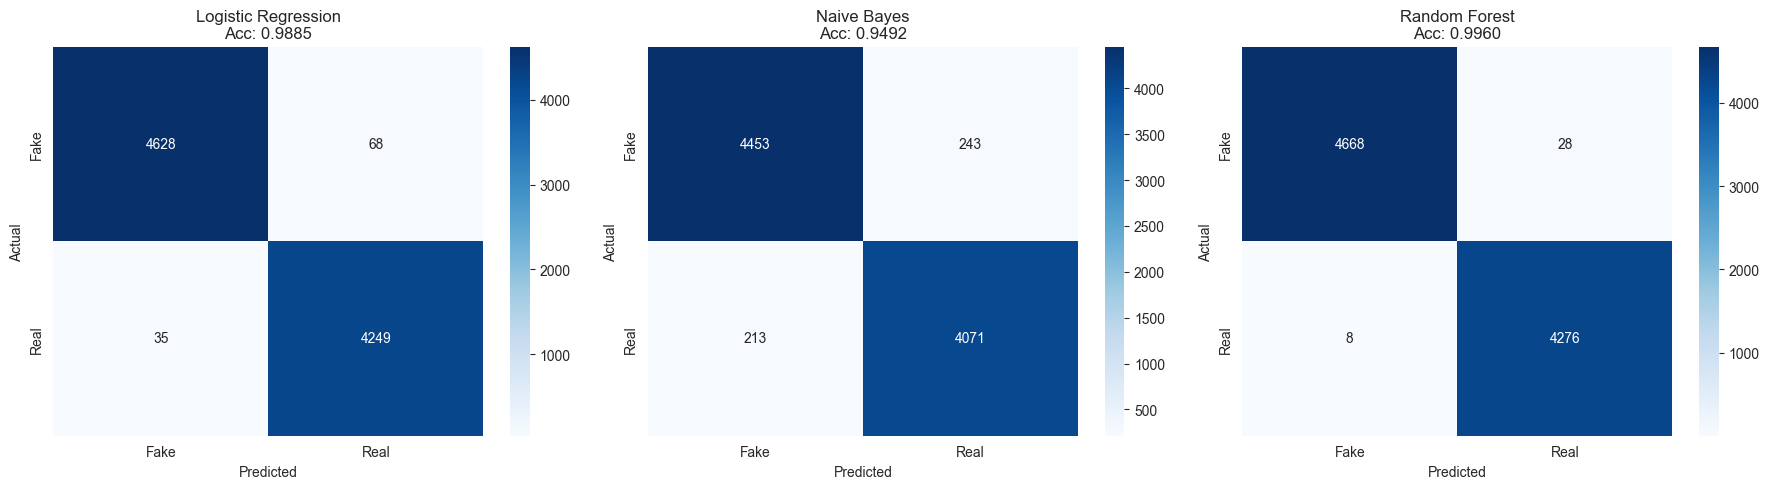

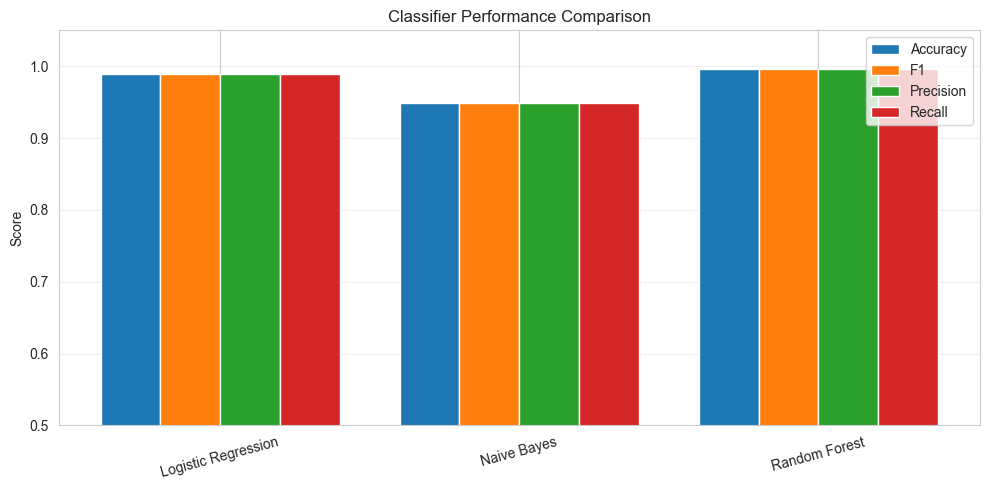


Classification Report: Logistic Regression
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Classification Report: Naive Bayes
              precision    recall  f1-score   support

        Fake       0.95      0.95      0.95      4696
        Real       0.94      0.95      0.95      4284

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980


Classification Report: Random Forest
              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00      4696
        Real       0.99      1.00      1.00      4284

    accuracy                           1.00      8980
   macro a

In [20]:
# Confusion matrices
plot_confusion_matrices(results)

# Performance comparison
plot_comparison(results)

# Detailed reports
print_classification_reports(results)

---
## 8b. Multi-Class News Category Classification

We classify each article into one of six topic categories:
**Politics, Technology, Sports, Entertainment, Business, Health**

Since the Fake/Real dataset does not carry explicit topic labels, we derive
ground-truth labels via **keyword matching** — each article is assigned the
category whose keyword list scores the most hits in the article text.
A TF-IDF + multi-class classifier is then trained and evaluated on these labels.

MULTI-CLASS NEWS CATEGORY CLASSIFICATION
Category distribution:
category
Politics         35310
Business          3127
Technology        2580
Sports            1820
Health            1175
Entertainment      886


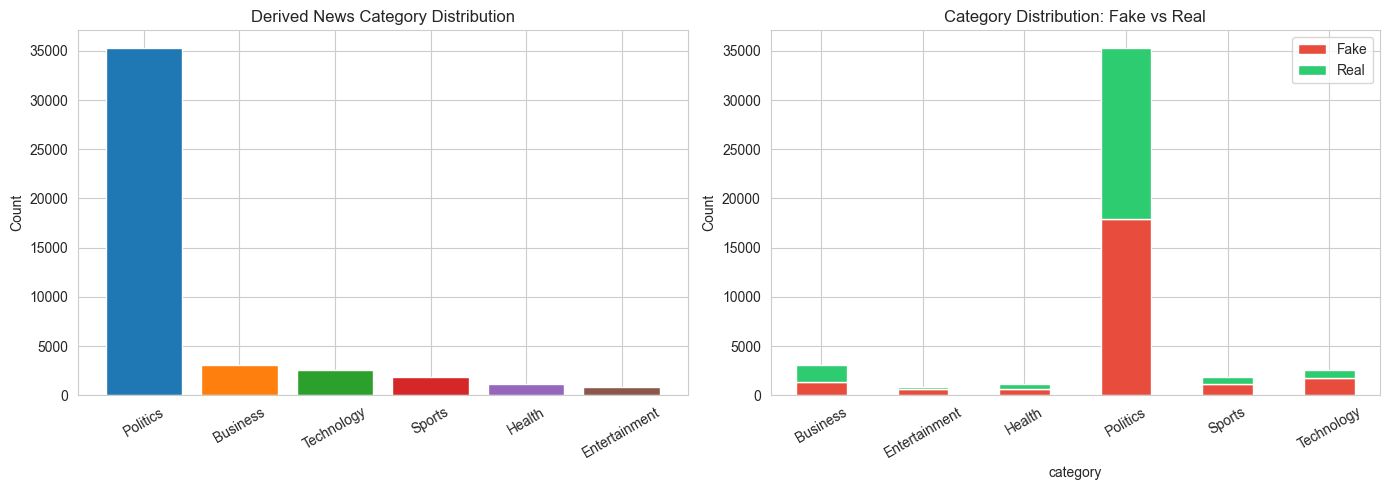

In [21]:
from src.classifiers import (prepare_category_labels, train_category_classifier,
                              plot_category_confusion_matrix, print_category_report)

# Step 1: Assign keyword-based category labels
print("=" * 60)
print("MULTI-CLASS NEWS CATEGORY CLASSIFICATION")
print("=" * 60)

df_cat = prepare_category_labels(df, text_col='text')

# Visualise category distribution
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category bar chart
cat_counts = df_cat['category'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values,
            color=sns.color_palette('tab10', len(cat_counts)))
axes[0].set_title('Derived News Category Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Category vs Fake/Real stacked bar
cross = df_cat.groupby(['category', 'label']).size().unstack(fill_value=0)
cross.columns = ['Fake', 'Real']
cross.plot(kind='bar', stacked=True, ax=axes[1],
           color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Category Distribution: Fake vs Real')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [23]:
# Reload module after fix
import importlib, src.classifiers
importlib.reload(src.classifiers)
from src.classifiers import train_category_classifier

# Step 2: Train multi-class category classifiers
cat_results, cat_encoder, cat_Xtr, cat_Xte, cat_ytr, cat_yte = train_category_classifier(
    tfidf_matrix, df_cat['category'].values
)

# Best category classifier (for use in the integrated pipeline)
best_cat_name = max(cat_results, key=lambda k: cat_results[k]['accuracy'])
best_cat_clf  = cat_results[best_cat_name]['model']
print(f"\nBest category classifier: {best_cat_name} "
      f"(Accuracy: {cat_results[best_cat_name]['accuracy']:.4f})")


Training Logistic Regression (category)...
  Accuracy: 0.8522 | F1: 0.8291 | Precision: 0.8383 | Recall: 0.8522

Training Naive Bayes (category)...
  Accuracy: 0.8092 | F1: 0.7611 | Precision: 0.7837 | Recall: 0.8092

Training Random Forest (category)...
  Accuracy: 0.8571 | F1: 0.8278 | Precision: 0.8740 | Recall: 0.8571

Best category classifier: Random Forest (Accuracy: 0.8571)


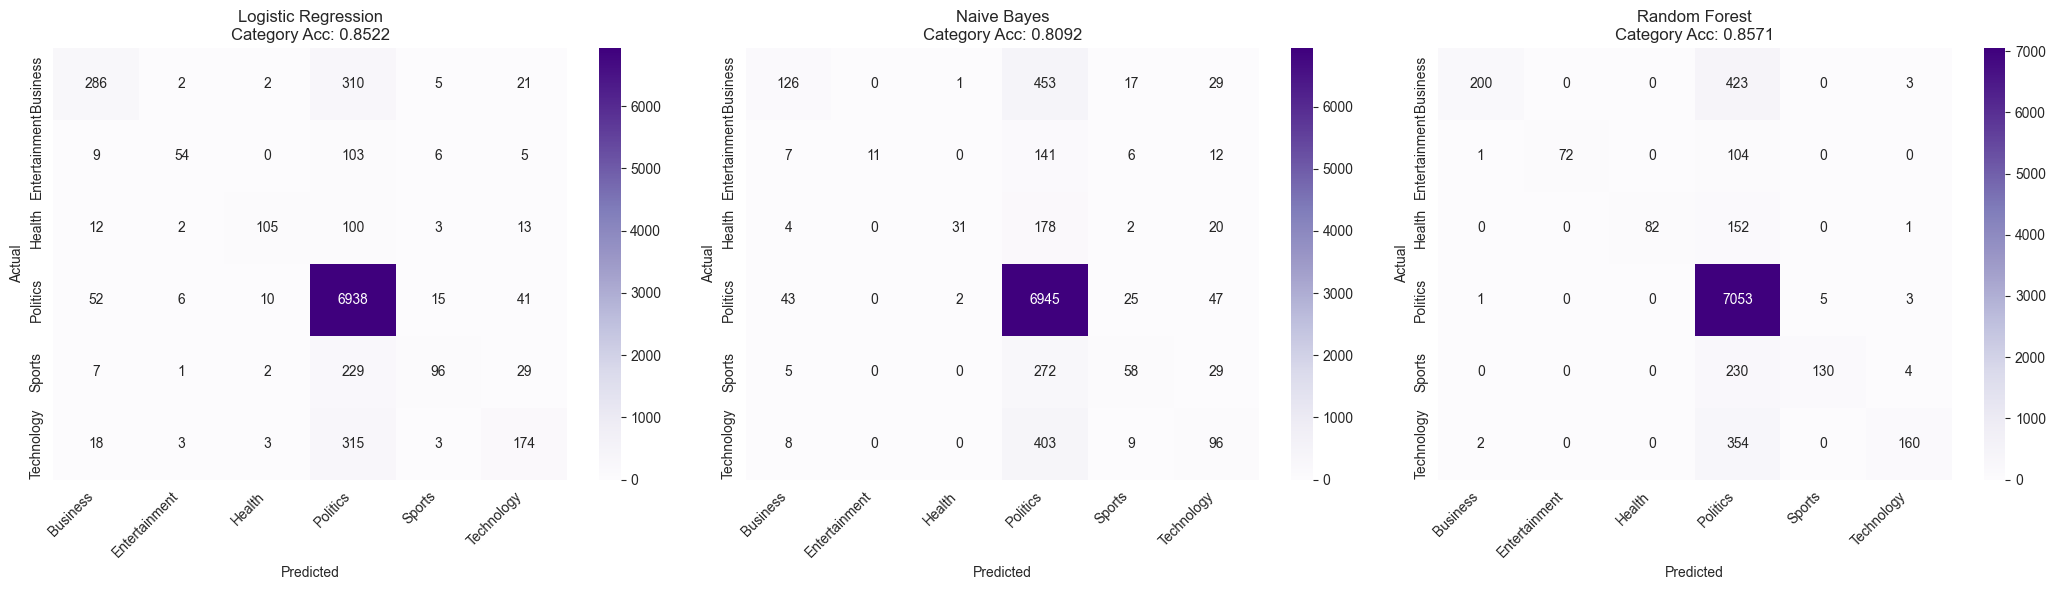


Category Classification Report: Logistic Regression
               precision    recall  f1-score   support

     Business       0.74      0.46      0.57       626
Entertainment       0.79      0.31      0.44       177
       Health       0.86      0.45      0.59       235
     Politics       0.87      0.98      0.92      7062
       Sports       0.75      0.26      0.39       364
   Technology       0.61      0.34      0.44       516

     accuracy                           0.85      8980
    macro avg       0.77      0.47      0.56      8980
 weighted avg       0.84      0.85      0.83      8980


Category Classification Report: Naive Bayes
               precision    recall  f1-score   support

     Business       0.65      0.20      0.31       626
Entertainment       1.00      0.06      0.12       177
       Health       0.91      0.13      0.23       235
     Politics       0.83      0.98      0.90      7062
       Sports       0.50      0.16      0.24       364
   Technology     

In [24]:
# Step 3: Evaluate — confusion matrices and detailed reports
plot_category_confusion_matrix(cat_results, cat_encoder)
print_category_report(cat_results, cat_encoder)

---
## 9. Fake News Detection - Deep Learning (LSTM)

We build an LSTM classifier using Word2Vec embeddings for fake news detection.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Prepare Word2Vec document vectors
print("Building document vectors from Word2Vec...")
from src.embeddings import get_document_vector_w2v

doc_vectors = np.array([get_document_vector_w2v(tokens, w2v_model) for tokens in df['tokens']])
print(f"Document vectors shape: {doc_vectors.shape}")

# Train-test split
X_dl_train, X_dl_test, y_dl_train, y_dl_test = train_test_split(
    doc_vectors, df['label'].values, test_size=0.2, random_state=42, stratify=df['label'].values)

# Convert to tensors
X_dl_train_t = torch.FloatTensor(X_dl_train).unsqueeze(1)  # Add seq dim
X_dl_test_t = torch.FloatTensor(X_dl_test).unsqueeze(1)
y_dl_train_t = torch.LongTensor(y_dl_train)
y_dl_test_t = torch.LongTensor(y_dl_test)

DL_BATCH = BATCH_SIZE   # reuse adaptive batch size from LM cell
train_ds = TensorDataset(X_dl_train_t, y_dl_train_t)
test_ds = TensorDataset(X_dl_test_t, y_dl_test_t)
train_dl = DataLoader(train_ds, batch_size=DL_BATCH, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=DL_BATCH)
print(f"BiLSTM batch size: {DL_BATCH}")

Building document vectors from Word2Vec...
Document vectors shape: (44898, 100)


Training BiLSTM Classifier...
  Epoch 5/20, Loss: 0.0616
  Epoch 10/20, Loss: 0.0496
  Epoch 15/20, Loss: 0.0403
  Epoch 20/20, Loss: 0.0336


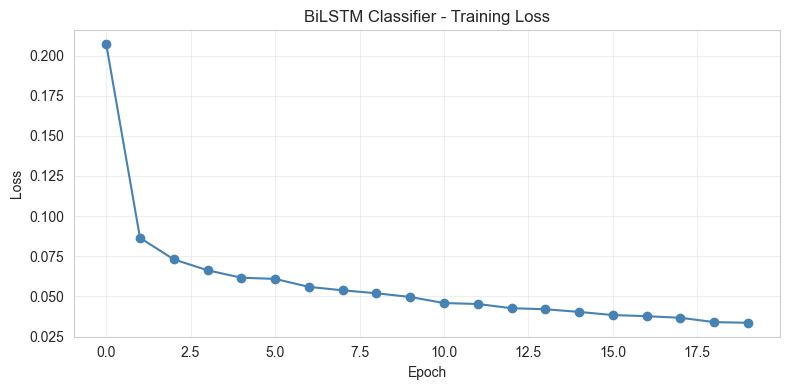

In [26]:
class LSTMClassifier(nn.Module):
    """BiLSTM classifier for fake news detection."""
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out

# Train LSTM classifier
lstm_clf = LSTMClassifier(input_dim=100).to(DEVICE)
optimizer = torch.optim.Adam(lstm_clf.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

lstm_losses = []
print("Training BiLSTM Classifier...")
for epoch in range(20):
    lstm_clf.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out = lstm_clf(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_dl)
    lstm_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/20, Loss: {avg_loss:.4f}")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(lstm_losses, marker='o', color='steelblue')
plt.title('BiLSTM Classifier - Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


BiLSTM CLASSIFIER RESULTS
Accuracy: 0.9826

              precision    recall  f1-score   support

        Fake       0.98      0.98      0.98      4696
        Real       0.98      0.98      0.98      4284

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



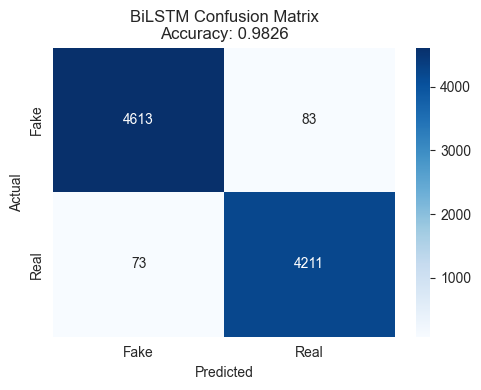

In [27]:
# Evaluate LSTM classifier
lstm_clf.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(DEVICE)
        out = lstm_clf(xb)
        preds = torch.argmax(out, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

print("\n" + "=" * 60)
print("BiLSTM CLASSIFIER RESULTS")
print("=" * 60)
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print("\n" + classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'], ax=ax)
ax.set_title(f'BiLSTM Confusion Matrix\nAccuracy: {accuracy_score(all_labels, all_preds):.4f}')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## 10. Integrated Analysis Pipeline

Enter any news article text and get a complete NLP analysis:
- Predicted category (Fake/Real)
- Keywords & Named Entities
- POS Tags
- Parsing results
- Prediction probabilities

In [28]:
from src.preprocessing import preprocess_text
from src.pos_tagging import pos_tag_text, extract_named_entities, extract_pos_categories
from src.parsing import dependency_parse
from src.embeddings import get_document_vector_w2v

def analyze_article(text, tfidf_vec, best_clf, w2v_model, nlp_model,
                    cat_clf=None, cat_encoder=None):
    """Complete NLP analysis pipeline for a news article."""
    print("=" * 70)
    print("INTEGRATED NEWS ARTICLE ANALYSIS")
    print("=" * 70)
    print(f"\nInput text (first 200 chars): {text[:200]}...")

    # 1. Preprocessing
    tokens = preprocess_text(text)
    processed = ' '.join(tokens)

    # 2. Fake News Detection (TF-IDF + best traditional classifier)
    tfidf_feat = tfidf_vec.transform([processed])
    pred  = best_clf.predict(tfidf_feat)[0]
    proba = best_clf.predict_proba(tfidf_feat)[0]
    label = 'REAL' if pred == 1 else 'FAKE'
    print(f"\n--- FAKE NEWS DETECTION ---")
    print(f"  Prediction: {label}")
    print(f"  Confidence: Fake={proba[0]:.4f}, Real={proba[1]:.4f}")

    # 3. News Category Prediction
    predicted_category = 'N/A'
    if cat_clf is not None and cat_encoder is not None:
        cat_pred_enc = cat_clf.predict(tfidf_feat)[0]
        predicted_category = cat_encoder.inverse_transform([cat_pred_enc])[0]
        if hasattr(cat_clf, 'predict_proba'):
            cat_proba = cat_clf.predict_proba(tfidf_feat)[0]
            cat_conf  = dict(zip(cat_encoder.classes_, [f'{p:.3f}' for p in cat_proba]))
            print(f"\n--- NEWS CATEGORY ---")
            print(f"  Predicted Category: {predicted_category}")
            print(f"  Category Scores   : {cat_conf}")
        else:
            print(f"\n--- NEWS CATEGORY ---")
            print(f"  Predicted Category: {predicted_category}")
    else:
        # Fallback: keyword-based category
        from src.classifiers import assign_news_category
        predicted_category = assign_news_category(text)
        print(f"\n--- NEWS CATEGORY (keyword-based) ---")
        print(f"  Predicted Category: {predicted_category}")

    # 4. Keywords
    print(f"\n--- KEYWORDS ---")
    print(f"  Top tokens: {tokens[:15]}")

    # 5. POS Tagging
    tagged     = pos_tag_text(text[:1000])
    categories = extract_pos_categories(tagged)
    print(f"\n--- POS TAGGING ---")
    print(f"  Nouns: {categories['nouns'][:10]}")
    print(f"  Verbs: {categories['verbs'][:10]}")

    # 6. Named Entities
    entities = extract_named_entities(text[:1000])
    print(f"\n--- NAMED ENTITIES (NLTK) ---")
    print(f"  {entities[:10]}")

    # 7. SpaCy NER
    doc        = nlp_model(text[:2000])
    sp_entities = [(ent.text, ent.label_) for ent in doc.ents]
    print(f"\n--- SPACY ENTITIES ---")
    print(f"  {sp_entities[:10]}")

    # 8. Parsing
    triples, _ = dependency_parse(text[:1000], nlp_model)
    print(f"\n--- PARSING (SVO Triples) ---")
    for t in triples[:5]:
        print(f"  {t['subject']} -- {t['verb']} --> {t['object']}")

    print("\n" + "=" * 70)
    return {
        'label':              label,
        'confidence':         proba,
        'predicted_category': predicted_category,
        'keywords':           tokens[:15],
        'entities':           sp_entities[:10],
        'triples':            triples[:5],
    }

In [29]:
# Select best fake-news classifier
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_clf  = results[best_name]['model']
print(f"Using best fake-news classifier: {best_name} "
      f"(Accuracy: {results[best_name]['accuracy']:.4f})")

# Test with sample articles
sample_real = df[df['label'] == 1]['text'].iloc[0]
sample_fake = df[df['label'] == 0]['text'].iloc[0]

print("\n" + "#" * 70)
print("TEST 1: Real News Article")
print("#" * 70)
analyze_article(sample_real, tfidf_vectorizer, best_clf, w2v_model, nlp,
                cat_clf=best_cat_clf, cat_encoder=cat_encoder)

print("\n" + "#" * 70)
print("TEST 2: Fake News Article")
print("#" * 70)
analyze_article(sample_fake, tfidf_vectorizer, best_clf, w2v_model, nlp,
                cat_clf=best_cat_clf, cat_encoder=cat_encoder)

Using best fake-news classifier: Random Forest (Accuracy: 0.9960)

######################################################################
TEST 1: Real News Article
######################################################################
INTEGRATED NEWS ARTICLE ANALYSIS

Input text (first 200 chars): SAN FRANCISCO (Reuters) - California Attorney General Xavier Becerra said on Friday he was “prepared to take whatever action it takes” to defend the Obamacare mandate that health insurers provide birt...

--- FAKE NEWS DETECTION ---
  Prediction: REAL
  Confidence: Fake=0.0200, Real=0.9800

--- NEWS CATEGORY ---
  Predicted Category: Politics
  Category Scores   : {'Business': '0.010', 'Entertainment': '0.000', 'Health': '0.050', 'Politics': '0.920', 'Sports': '0.000', 'Technology': '0.020'}

--- KEYWORDS ---
  Top tokens: ['san', 'francisco', 'reuters', 'california', 'attorney', 'general', 'xavier', 'becerra', 'said', 'friday', 'prepared', 'take', 'whatever', 'action', 'take']

--- POS TAGGI

{'label': 'FAKE',
 'confidence': array([0.99, 0.01]),
 'predicted_category': 'Politics',
 'keywords': ['donald',
  'trump',
  'white',
  'house',
  'chaos',
  'trying',
  'cover',
  'russia',
  'problem',
  'mounting',
  'hour',
  'refuse',
  'acknowledge',
  'problem',
  'surrounding'],
 'entities': [('Donald Trump', 'PERSON'),
  ('White House', 'ORG'),
  ('Russia', 'GPE'),
  ('the hour', 'TIME'),
  ('Congressional', 'NORP'),
  ('Chuck Grassley', 'PERSON'),
  ('the Senate Judiciary Committee', 'ORG'),
  ('Donald Trump', 'PERSON'),
  ('Jr.', 'PERSON'),
  ('2016', 'DATE')],
 'triples': [{'subject': 'House', 'verb': 'is', 'object': ''},
  {'subject': 'they', 'verb': 'trying', 'object': ''},
  {'subject': 'problems', 'verb': 'mounting', 'object': ''},
  {'subject': 'they', 'verb': 'refuse', 'object': ''},
  {'subject': 'it', 'verb': 's', 'object': 'news'}]}

In [30]:
# Test with custom text
custom_text = """
The government announced a new policy to regulate artificial intelligence 
technology in the healthcare sector. The president signed the executive order 
during a press conference at the White House. Officials said the new regulations 
would protect patient privacy while encouraging innovation in medical AI applications.
"""

print("#" * 70)
print("TEST 3: Custom News Article")
print("#" * 70)
analyze_article(custom_text, tfidf_vectorizer, best_clf, w2v_model, nlp,
                cat_clf=best_cat_clf, cat_encoder=cat_encoder)

######################################################################
TEST 3: Custom News Article
######################################################################
INTEGRATED NEWS ARTICLE ANALYSIS

Input text (first 200 chars): 
The government announced a new policy to regulate artificial intelligence 
technology in the healthcare sector. The president signed the executive order 
during a press conference at the White House....

--- FAKE NEWS DETECTION ---
  Prediction: FAKE
  Confidence: Fake=0.5800, Real=0.4200

--- NEWS CATEGORY ---
  Predicted Category: Politics
  Category Scores   : {'Business': '0.030', 'Entertainment': '0.000', 'Health': '0.260', 'Politics': '0.550', 'Sports': '0.000', 'Technology': '0.160'}

--- KEYWORDS ---
  Top tokens: ['government', 'announced', 'new', 'policy', 'regulate', 'artificial', 'intelligence', 'technology', 'healthcare', 'sector', 'president', 'signed', 'executive', 'order', 'press']

--- POS TAGGING ---
  Nouns: ['government', 'policy', 'in

{'label': 'FAKE',
 'confidence': array([0.58, 0.42]),
 'predicted_category': 'Politics',
 'keywords': ['government',
  'announced',
  'new',
  'policy',
  'regulate',
  'artificial',
  'intelligence',
  'technology',
  'healthcare',
  'sector',
  'president',
  'signed',
  'executive',
  'order',
  'press'],
 'entities': [('the White House', 'FAC')],
 'triples': [{'subject': 'government',
   'verb': 'announced',
   'object': 'policy'},
  {'subject': 'president', 'verb': 'signed', 'object': 'order'},
  {'subject': 'Officials', 'verb': 'said', 'object': ''},
  {'subject': 'regulations', 'verb': 'protect', 'object': 'privacy'}]}

---
## 11. Save Models

In [31]:
import pickle

os.makedirs('models', exist_ok=True)

# Save Word2Vec
w2v_model.save('models/word2vec.model')

# Save TF-IDF vectorizer
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# Save best fake-news classifier
with open('models/best_classifier.pkl', 'wb') as f:
    pickle.dump(best_clf, f)

# Save category classifier + encoder
with open('models/category_classifier.pkl', 'wb') as f:
    pickle.dump({'model': best_cat_clf, 'encoder': cat_encoder}, f)

# Save HMM classifier
with open('models/hmm_classifier.pkl', 'wb') as f:
    pickle.dump(hmm_clf, f)

# Save LSTM models
torch.save(lm_model.state_dict(), 'models/lstm_lm.pth')
torch.save(lstm_clf.state_dict(), 'models/lstm_classifier.pth')

print("All models saved to models/ directory.")

Word2Vec model saved to models/word2vec.model
All models saved to models/ directory.


---
## 12. Performance Summary

### Results Table

In [33]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import pandas as pd

# ── Fake News Detection Summary ──────────────────────────────────────────────
summary_data = []
for name, res in results.items():
    summary_data.append({
        'Model': name,
        'Task': 'Fake News Detection',
        'Accuracy': f"{res['accuracy']:.4f}",
        'F1-Score': f"{res['f1']:.4f}",
        'Precision': f"{res['precision']:.4f}",
        'Recall': f"{res['recall']:.4f}",
    })

# Add BiLSTM results
lstm_acc = accuracy_score(all_labels, all_preds)
summary_data.append({
    'Model': 'BiLSTM (W2V)',
    'Task': 'Fake News Detection',
    'Accuracy': f"{lstm_acc:.4f}",
    'F1-Score': f"{f1_score(all_labels, all_preds, average='weighted'):.4f}",
    'Precision': f"{precision_score(all_labels, all_preds, average='weighted'):.4f}",
    'Recall': f"{recall_score(all_labels, all_preds, average='weighted'):.4f}",
})

# Add HMM results
summary_data.append({
    'Model': 'HMM (entropy+state)',
    'Task': 'Fake News Detection',
    'Accuracy': f"{hmm_acc:.4f}",
    'F1-Score': f"{hmm_f1:.4f}",
    'Precision': 'N/A',
    'Recall': 'N/A',
})

# ── Category Classification Summary ──────────────────────────────────────────
for name, res in cat_results.items():
    summary_data.append({
        'Model': name,
        'Task': 'Category Classification',
        'Accuracy': f"{res['accuracy']:.4f}",
        'F1-Score': f"{res['f1']:.4f}",
        'Precision': f"{res['precision']:.4f}",
        'Recall': f"{res['recall']:.4f}",
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 80)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))


FINAL PERFORMANCE SUMMARY
              Model                    Task Accuracy F1-Score Precision Recall
Logistic Regression     Fake News Detection   0.9885   0.9885    0.9886 0.9885
        Naive Bayes     Fake News Detection   0.9492   0.9492    0.9493 0.9492
      Random Forest     Fake News Detection   0.9960   0.9960    0.9960 0.9960
       BiLSTM (W2V)     Fake News Detection   0.9826   0.9826    0.9826 0.9826
HMM (entropy+state)     Fake News Detection   0.7008   0.6843       N/A    N/A
Logistic Regression Category Classification   0.8522   0.8291    0.8383 0.8522
        Naive Bayes Category Classification   0.8092   0.7611    0.7837 0.8092
      Random Forest Category Classification   0.8571   0.8278    0.8740 0.8571


---
## Conclusion

This project successfully demonstrates an end-to-end NLP pipeline for news article classification and fake news detection. Key findings:

1. **TF-IDF + Logistic Regression** provides a strong baseline with high accuracy
2. **Word2Vec embeddings** capture semantic relationships between news terms
3. **LSTM language model** learns contextual patterns in news text
4. **POS tagging and NER** extract meaningful entities and keywords
5. **HMM** models POS tag transition patterns that differ between fake and real news
6. **Dependency parsing** reveals structural relationships in news sentences

## Future Scope

1. **BERT/Transformer models** for improved contextual understanding
2. **Multi-class category classification** with larger datasets
3. **Attention mechanisms** for explainable predictions
4. **Real-time web scraping** for live news analysis
5. **Cross-lingual fake news detection**
6. **Graph-based approaches** for source credibility analysis

---

## Viva Questions & Answers

**Q1: What is TF-IDF and why is it useful?**
A: TF-IDF (Term Frequency-Inverse Document Frequency) measures word importance in a document relative to a corpus. It gives high weight to words that appear frequently in a document but rarely across all documents, making it useful for text classification.

**Q2: How does Word2Vec work?**
A: Word2Vec uses a shallow neural network to learn word embeddings. It has two architectures: CBOW (predicts target word from context) and Skip-gram (predicts context from target word). Words appearing in similar contexts get similar vector representations.

**Q3: What is an HMM and how is it used in NLP?**
A: A Hidden Markov Model is a probabilistic model with hidden states and observable emissions. In NLP, it's used for POS tagging where hidden states are POS tags and observations are words. It uses transition probabilities (tag→tag) and emission probabilities (tag→word).

**Q4: What is dependency parsing?**
A: Dependency parsing analyzes grammatical structure by establishing relationships between words. Each word is connected to a head word via a dependency relation (e.g., nsubj, dobj), forming a tree structure that reveals who did what to whom.

**Q5: Why use LSTM for text classification?**
A: LSTMs (Long Short-Term Memory) can capture long-range dependencies in text through their gating mechanism. They process text sequentially, maintaining a memory cell that selectively remembers or forgets information, making them effective for understanding context.

**Q6: What is the difference between stemming and lemmatization?**
A: Stemming chops off word endings using rules (e.g., 'running'→'run'), sometimes producing non-words. Lemmatization uses vocabulary and morphological analysis to return valid dictionary forms (e.g., 'better'→'good'). Lemmatization is more accurate but slower.

**Q7: How do you detect fake news using NLP?**
A: Fake news detection uses text features like writing style, sentiment, word choice patterns, and linguistic cues. We extract features using TF-IDF or word embeddings, then train classifiers (LR, NB, RF, LSTM) to distinguish fake from real news based on these patterns.

**Q8: What evaluation metrics are used and why?**
A: Accuracy (overall correctness), Precision (of predicted positives, how many are correct), Recall (of actual positives, how many are found), F1-Score (harmonic mean of precision and recall). F1 is especially important for imbalanced datasets.

**Q9: What is Named Entity Recognition?**
A: NER identifies and classifies named entities in text into categories like Person, Organization, Location, Date, etc. It helps extract key information from news articles for understanding who, what, where, and when.

**Q10: What is the role of embeddings in NLP?**
A: Embeddings convert words/documents into dense numerical vectors that capture semantic meaning. Similar words have similar vectors, enabling mathematical operations on language (e.g., king - man + woman ≈ queen).